In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
%matplotlib inline
sns.set_theme()

# <div align="center"> 1. Introduction</div>
- This analysis explores how market sentiment (Fear/Greed) influences trader behavior and performance.
- We align trade-level data with daily sentiment regimes and evaluate behavioral and performance changes across different market conditions.
----
# <div align = "center">Methodology</div> 
- **Trade data was aggregated to daily trader-level metrics**
- **Sentiment data was merged based on date (daywise)**
- **Behavioral (Frequency,size,direction) and performance(PnL,efficiency) metrics were analyzed**
- **Segmentation was performed based on risk,activity and consistency**

# Loading the Data & Inspection

In [2]:
df1 = pd.read_csv('/kaggle/input/datasets/harrykesh/primetrade/fear_greed_index.csv')
df2 = pd.read_csv('/kaggle/input/datasets/harrykesh/primetrade/historical_data.csv')

display(df1.head())
display(df2.head())

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Basic Checks

In [3]:
def inspect(df:pd.DataFrame,filename:str) -> None:
    print("="*5)
    print(f"Filename: {filename}")
    print(f'Shape: {df.shape}')
    print(f"Missing:\n{df.isnull().sum()}")
    print(f"Duplicates: {df.duplicated().sum()}")
    print("="*5)


inspect(df1,'Sentiment')
inspect(df2,'Historical')

=====
Filename: Sentiment
Shape: (2644, 4)
Missing:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0
=====
=====
Filename: Historical
Shape: (211224, 16)
Missing:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0
=====


In [4]:
display(df1.info())
print("="*10)
display(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

None

> we noticed no trivial errors in the dataset

# 2. Cleaning & Aligning
- Trade-level data was aggregated to daily level to align with sentiment data, which is available at a daily granularity.
- This ensures consistent comparison of trader performance under different market regimes

In [5]:
df1['date'] = pd.to_datetime(df1['date']).dt.date
df2['Timestamp IST'] = pd.to_datetime(df2['Timestamp IST'],dayfirst = True)

##converting time stamps to daywise dates - inorder to match the first table upon merging
df2['date'] = df2['Timestamp IST'].dt.date

display(df1.head())
display(df2.head())

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [6]:
df = df2.merge(
    df1[['date','classification']],
    on = "date",
    how = "left"
)

print(df.shape)
print(df['classification'].isnull().sum())
display(df.head())

(211224, 18)
6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


> all the rows from the left table (df2) and the matching rows from the right table (df1) are included in the df table
>
> 6 rows in the df2 table have no matching rows in the df1 table

## Cross Checking the Merge

<Axes: xlabel='classification'>

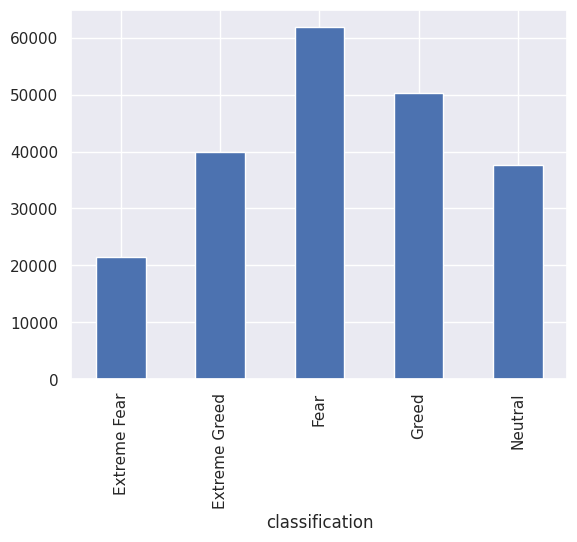

In [7]:
df.groupby("classification").size().plot(kind='bar')

# 3. Feature Engineering 
1. Daily PnL per Trader (master table from the merged table)
2. Number of trades per day
3. Average Position size
4. Total sum of PnL
5. Win Rate (closed PnL > 0, aggregated mean over the account for each day)
6. Avg Profit and Loss
7. Volatility of PnL

- These features capture trade performance and behaviour
- some additional features were derived during analysis which are not listed here

## A. Creating the daily PnL per Trader
- The intraday trades will be aggregated per trader (by account) per day (by date) to get the master dataset from which necessary KPIs can be derived
- This was done to maintain the temporal granularity in both the initial datasets

In [8]:
daily = df.groupby(
    ['Account','date','classification']
).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
}).reset_index()
daily.head()

,Account,date,classification,Closed PnL,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,17248.148148


## B. Adding number of trades per day

In [9]:
## adding trades per day for each Account
trades_per_day = df.groupby(['Account','date']).size().reset_index(name='num_trades')

daily = daily.merge(trades_per_day,on = ['Account','date'])

daily.head()

,Account,date,classification,Closed PnL,Size USD,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,5089.718249,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,7976.664412,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,23734.500000,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,28186.666667,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,17248.148148,27


## C. Incorporating Win rate

In [10]:
## adding Wins (PnL > 0)
df['Win'] = df['Closed PnL'] > 0

win_rate = df.groupby(["Account","date"])['Win'].mean().reset_index(name='win_rate')


daily = daily.merge(win_rate,on=["Account","date"])

daily.head()

,Account,date,classification,Closed PnL,Size USD,num_trades,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,5089.718249,177,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,7976.664412,68,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,23734.500000,40,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,28186.666667,12,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,17248.148148,27,0.444444


In [11]:
daily['efficiency'] = daily['Closed PnL'] / daily['num_trades']

profit = df[df['Closed PnL'] > 0].groupby('classification')['Closed PnL'].sum()
loss = df[df['Closed PnL'] < 0].groupby('classification')['Closed PnL'].sum().abs()

profit_factor = profit / loss


avg_profit = df[df['Closed PnL'] > 0].groupby('classification')['Closed PnL'].mean()
avg_loss = df[df['Closed PnL'] < 0].groupby('classification')['Closed PnL'].mean()


# 4. Analysis

## 4.1 Performance v/s Sentiment

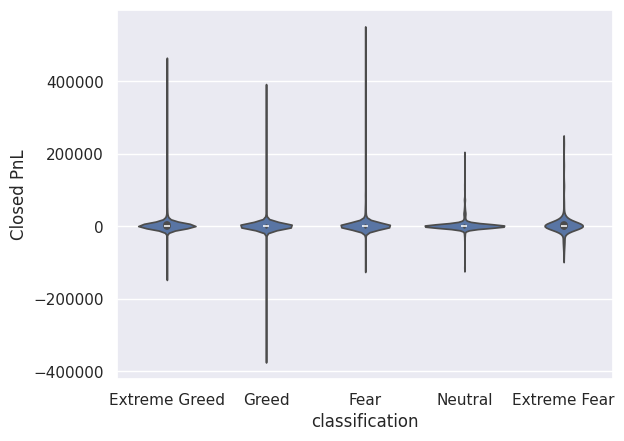

In [12]:
sns.violinplot(
    data=daily,
    y = "Closed PnL",
    x = "classification"
)
plt.show()

> PnL distribution varies across sentiment regimes, with higher variance observed during Fear periods, indicating increased market instability

## 4.2 Behaviour v/s Sentiment

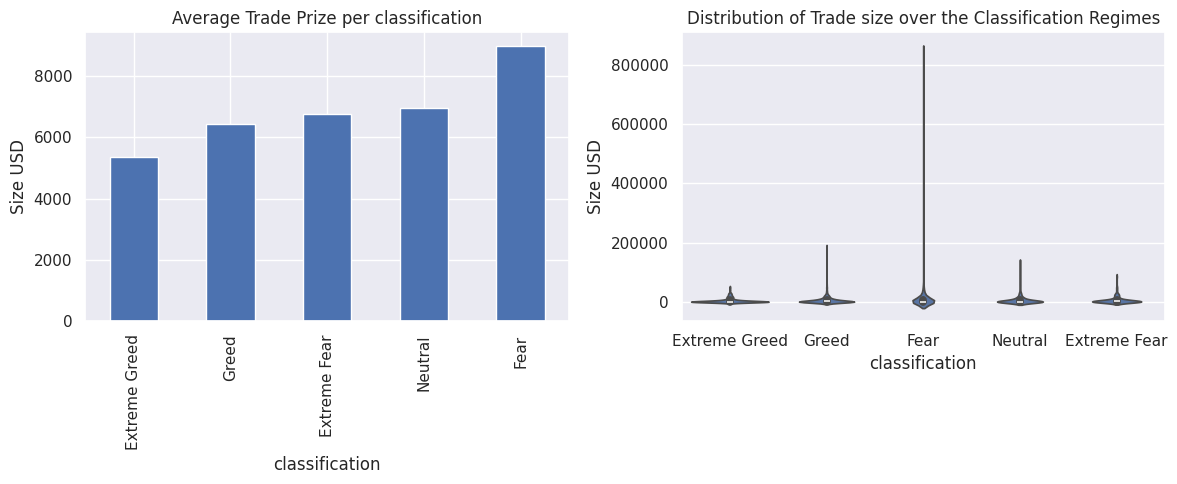

In [13]:
## Trade Size analysis 
fig,ax = plt.subplots(1,2,figsize=(12,5))
daily.groupby('classification')['Size USD'].mean().sort_values().plot(kind='bar',ax=ax[0])
ax[0].set_title('Average Trade Prize per classification')
ax[0].set_ylabel('Size USD')

sns.violinplot(
    data=daily,
    y = "Size USD",
    x = "classification",
    ax=ax[1]
)
ax[1].set_title("Distribution of Trade size over the Classification Regimes")
plt.tight_layout()

> Average trade size increases during Fear regimes, with higher dispersion in the distribution.

> This suggests traders take larger and more inconsistent positions during uncertain market conditions, very likely driven by recovery attempts or emotional decision-making.

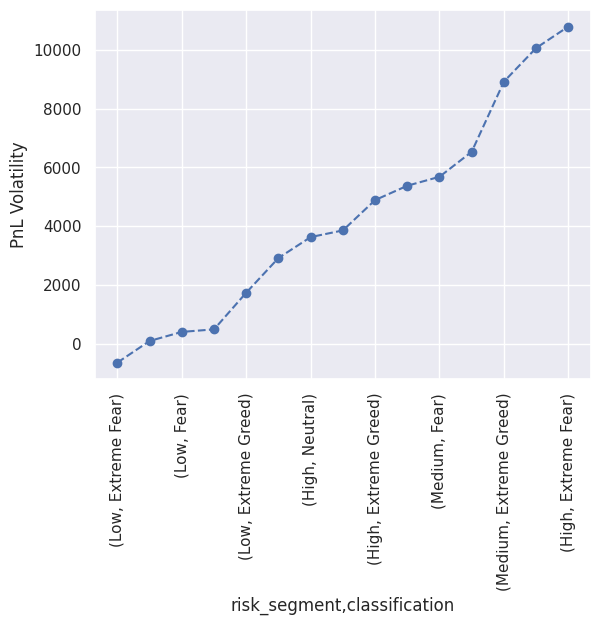

In [14]:
##RISK volatility : std deviation of SIZE USD grouped by classification

risk_vol = daily.groupby('classification')['Size USD'].std()
daily['risk_segment'] = pd.qcut(daily['Size USD'],3,labels= ["Low","Medium","High"])
daily.groupby(['risk_segment','classification'])['Closed PnL'].mean().sort_values().plot(kind='line',marker='o',linestyle='--')
plt.xticks(rotation=90)
plt.ylabel('PnL Volatility')
plt.show()

> High-risk traders (large position sizes) exhibit significantly higher PnL variability, particularly during Fear periods.

> This indicates that aggressive risk-taking amplifies both gains and losses under volatile conditions.

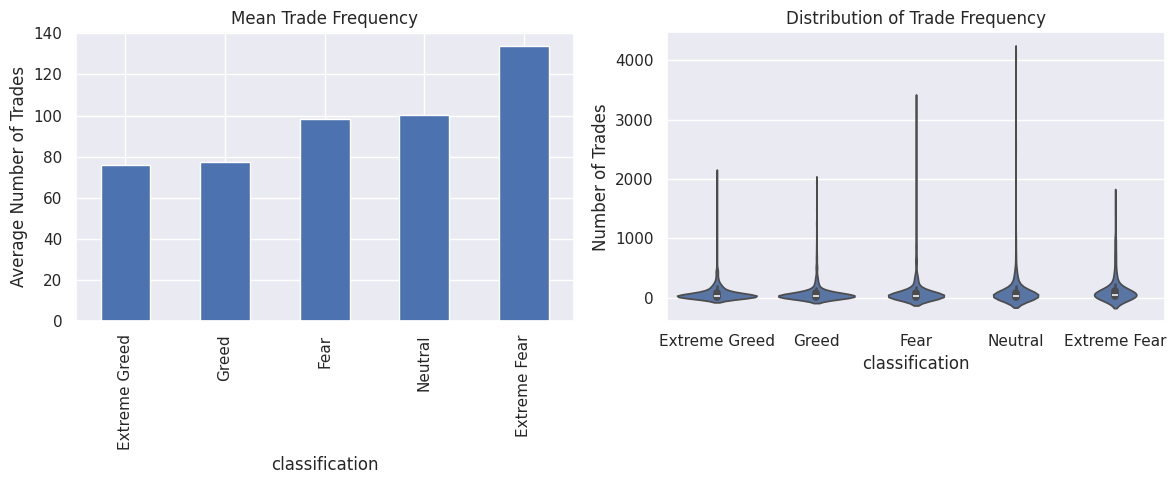

In [25]:
## Trade frequency analysis
fig,ax = plt.subplots(1,2,figsize=(12,5))
daily.groupby('classification')['num_trades'].mean().sort_values().plot(kind='bar',ax=ax[0])
ax[0].set_ylabel('Average Number of Trades')
ax[0].set_title('Mean Trade Frequency')
sns.violinplot(
    data=daily,
    x = "classification",
    y = "num_trades",
    ax=ax[1]
)
ax[1].set_title('Distribution of Trade Frequency')
ax[1].set_ylabel('Number of Trades')
plt.tight_layout()

> Directional bias shifts across sentiment regimes, with traders exhibiting a higher long bias during Greed periods.

> This indicates trend-following behavior, whereas shift towards short positions during Fear suggest defensive or reactive positioning.

## 4.3 Win Rate vs PnL comparisson

<Axes: xlabel='win_rate', ylabel='Closed PnL'>

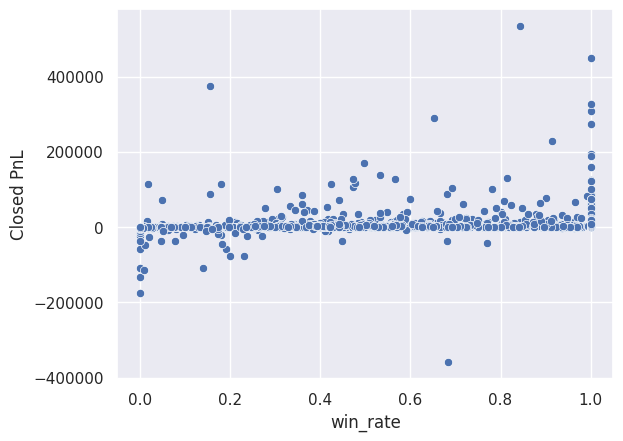

In [16]:
sns.scatterplot(data=daily,x='win_rate',y='Closed PnL')

> There is weak correlation between win rate and PnL, indicating that profitability is driven by a small number of trades rather than consistent wins.

## 4.4 Long/Short Ratio v/s Behaviour

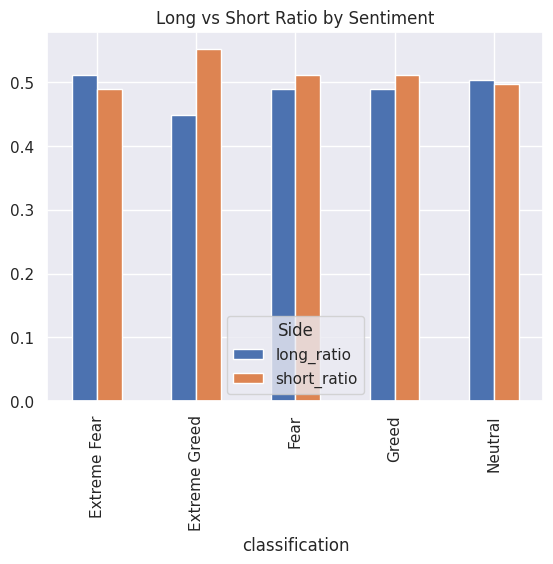

In [17]:
direction = df.groupby(['classification','Side']).size().unstack(fill_value=0)

direction['long_ratio'] = direction['BUY']/ (direction['BUY'] + direction['SELL'])
direction['short_ratio'] = direction['SELL'] / (direction['BUY'] + direction['SELL'])

direction[['long_ratio','short_ratio']].plot(kind='bar')
plt.title("Long vs Short Ratio by Sentiment")
plt.show()

> Directional bias remains balanced across all sentiment regimes, with long and short ratios staying close to equal.

> Interestingly, during Extreme Greed, traders exhibit a higher proportion of short positions, suggesting potential contrarian behavior rather than pure trend-following.

> Similarly, the absence of a strong long bias during Greed phases indicates that traders are not uniformly chasing upward trends, but may be engaging in more complex or hedged strategies.

> Overall, directional positioning appears less sensitive to market sentiment compared to trading frequency and position sizing.

## 4.5 Performance Efficiency v/s Behaviour

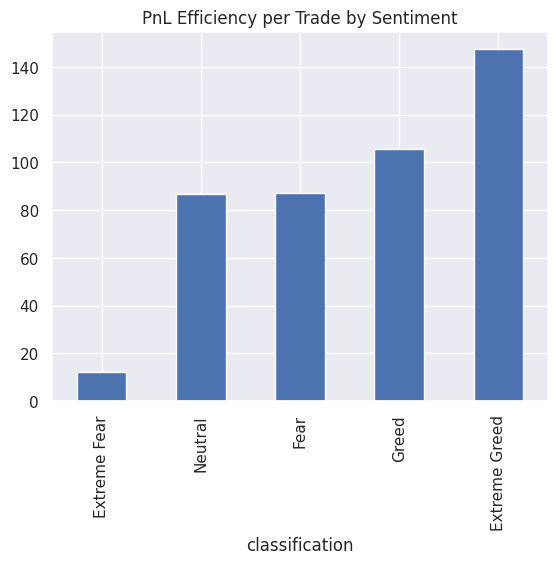

In [18]:
daily.groupby('classification')['efficiency'].mean().sort_values().plot(kind='bar')
plt.title("PnL Efficiency per Trade by Sentiment")
plt.show()

> Despite increased trading activity during Fear regimes, efficiency (PnL per trade) declines.

> This confirms that additional trades do not translate into better outcomes, reinforcing the presence of overtrading inefficiency.

## 4.6 Profitability v/s Behaviour

Text(0, 0.5, 'Profitability Factor (Profit/Loss)')

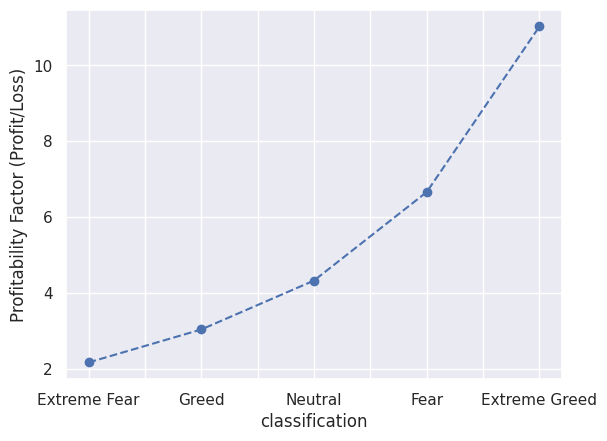

In [19]:
profit_factor.sort_values().plot(marker='o',linestyle='--')
plt.ylabel('Profitability Factor (Profit/Loss)')

> Profit factor increases significantly during Greed and Extreme Greed regimes, indicating that traders are substantially more profitable in strong market conditions.

> In contrast, profitability drops sharply during Extreme Fear periods, suggesting that traders struggle to generate returns during high uncertainty and volatility.

> This highlights a strong dependence of trader performance on market regime, with strategies performing better in trending markets than in stressed conditions.

## 4.7 Trade Frequency and PnL relation

<Axes: xlabel='num_trades', ylabel='Closed PnL'>

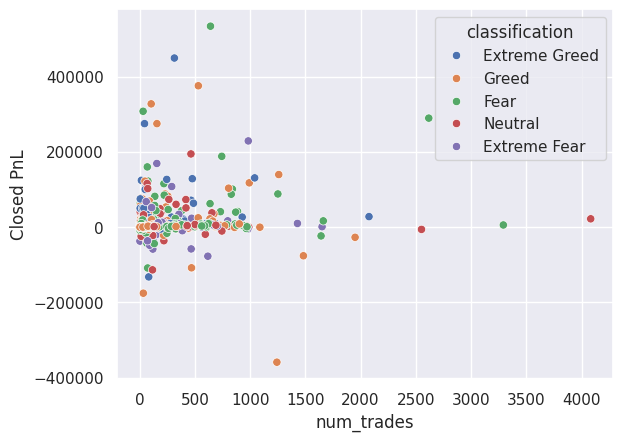

In [20]:
sns.scatterplot(
    data=daily,
    x='num_trades',
    y='Closed PnL',
    hue='classification'
)

> There is no strong positive relationship between trade frequency and PnL.

> In many cases, higher activity corresponds to lower profitability, further supporting the hypothesis of inefficient overtrading.

## 4.8 Risk (using the position size as proxy for risk) Segmentation

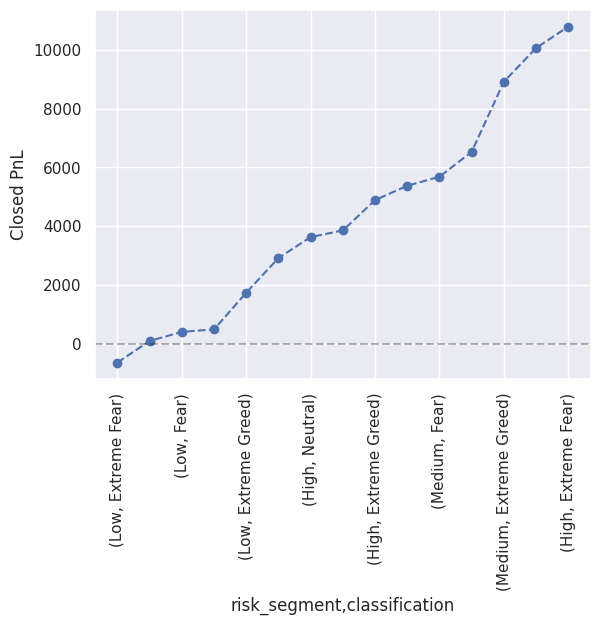

In [21]:
daily.groupby(['risk_segment','classification'])['Closed PnL'].mean().sort_values().plot(marker='o',linestyle='--')
plt.xticks(rotation=90)
plt.ylabel('Closed PnL')
plt.axhline(y=0,linestyle='--',color='black',alpha=.3)
plt.show()

> High-risk traders exhibit significantly higher volatility and lower consistency during Fear regimes, indicating amplified downside risk

## 4.9 Frequency Segmentation

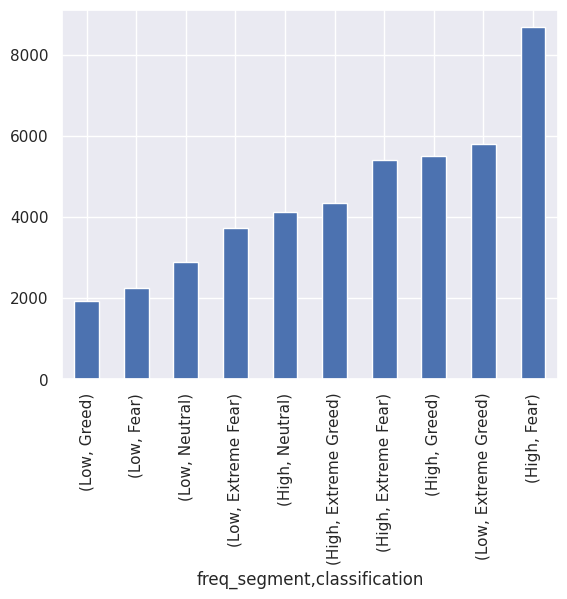

In [22]:
freq = daily.groupby('Account')['num_trades'].mean()
threshold = freq.median()

daily['freq_segment'] = daily['Account'].map(
    lambda x: 'High' if freq[x] > threshold else 'Low'
)

daily.groupby(['freq_segment','classification'])['Closed PnL'].mean().sort_values().plot(kind='bar')
plt.show()

> High-frequency traders increase activity during Fear but do not achieve better performance, suggesting inefficiency due to overtrading.

## 4.10 Consistency Segmentation

<Axes: xlabel='consistency,classification'>

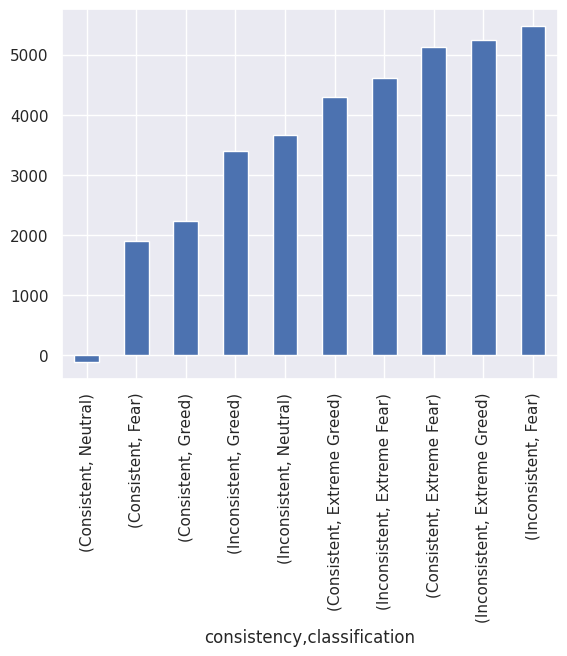

In [23]:
consistency = daily.groupby('Account')['win_rate'].mean()

daily['consistency'] = daily['Account'].map(
    lambda x: 'Consistent' if consistency[x] > 0.6 else 'Inconsistent'
)

daily.groupby(['consistency','classification'])['Closed PnL'].mean().sort_values().plot(kind='bar')

> Consistent traders maintain relatively stable performance across sentiment regimes, indicating robustness to market conditions.

# 5. Key Insights

1. It was observed that trading activity was heightened during regimes realted to Fear, pointing to panic driven behaviour rather than strategic planning.
2. In periods of Fear position size (Size USD) increases significantly, which should be attributed to risk-seeking behaviour of drawdowns.
3. Win rate and Profitability ironically had a weak correlation, pointing to the fact that small number of high volume trades dominate returns.
4. As discussed above during Fear regimes trade frequency increases, but the efficiency of the trades decreases due to inefficient risk taking behaviour.
5. Long-Short ratio analysis tells that traders shift there trade directions to follow the trend during Greed phases.

# 6. Strategy Recommendation
- [x] Limit trading frequency during times of Fear to avoid the overtrading losses
- [x] Cap trade position sizes during high volatility periods to reduct risk amplification
- [x] Focus on few large wins rather than maximizing win rate (as proved by Key insight #3)

In [24]:
## exporting the tables 
df.to_csv('merged.csv',index=False)
daily.to_csv('daily.csv',index=False)
direction.to_csv('direction_of_trade.csv',index=False)